
# DPO: Your language model is secretely a reward model (Implementation & Reproduction) - Session 2 

In [ ]:

# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 1 — Install (run once, restart kernel after)      ║
# ╚══════════════════════════════════════════════════════════╝
import subprocess, sys

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "--upgrade",
    "transformers==4.44.2",
    "tokenizers>=0.19.0",
    "accelerate>=0.33.0",
])
print("Installation done.")
print("NOW: Runtime → Restart Kernel, then run from Cell 2")


Transformers : 5.0.0
PyTorch      : 2.10.0+cu128
GPU          : Tesla T4
VRAM         : 15.6 GB
Device       : cuda
Steps/session : 600
Total target  : 3000
LR            : 1e-06
Warmup steps  : 150

SESSION 2 — Resuming from step 600
  Checkpoint: /kaggle/working/dpo_outputs/checkpoints/step_600
  This session : step 600 → 1200


  [VRAM before loading] 0.00/15.6 GB

Loading tokenizer ...
Loading policy model from: /kaggle/working/dpo_outputs/checkpoints/step_600


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loading reference model (always base) ...


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [VRAM after loading both models] 2.89/15.6 GB
Policy model params: 355M
Models ready.
DPO loss ready.
Loading dataset ...
Train batches : 1250
Val   batches : 100
  History loaded: 24 entries, up to step 600

  SESSION 2 | Steps 601 → 1200
  β=0.1 | lr=1e-06 | batch=4
Step   625 | loss=0.6999 (-1.0%) | rw=+0.030 | rl=+0.043 | gap=-0.013 | ETA 13m
Step   650 | loss=3.0199 (-335.7%) | rw=-2.826 | rl=+0.000 | gap=-2.826 | ETA 13m
Step   675 | loss=0.7008 (-1.1%) | rw=+0.050 | rl=+0.062 | gap=-0.012 | ETA 12m
Step   700 | loss=0.6441 (+7.1%) | rw=-0.537 | rl=-0.863 | gap=+0.325 | ETA 12m
Step   725 | loss=0.5796 (+16.4%) | rw=-0.071 | rl=-0.360 | gap=+0.289 | ETA 12m
Step   750 | loss=0.8119 (-17.1%) | rw=-0.165 | rl=+0.029 | gap=-0.194 | ETA 11m
Step   775 | loss=0.5389 (+22.3%) | rw=+0.622 | rl=-1.671 | gap=+2.293 | ETA 10m
Step   800 | loss=3.4499 (-397.7%) | rw=-3.212 | rl=-0.214 | gap=-2.997 | ETA 10m
         → val=1.0616 (-53.2% below baseline) ★
Step   825 | loss=0.7306 (-5.4%) |

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  Model saved  → checkpoints/step_1200/
  ZIP saved    → zipped/checkpoint_step_1200.zip  (1319 MB)
  History saved → 48 total entries

  ← This ZIP file will appear in Kaggle Output tab
  ← Download it to continue in next session

Session 2 done in 16.7 min
Progress: 1200 / 3000 steps

HOW TO CONTINUE TO NEXT SESSION:
1. Go to Kaggle Output tab (right side panel)
2. Find: dpo_outputs/zipped/checkpoint_step_1200.zip
3. Download that ZIP file to your computer
4. Go to kaggle.com/datasets → New Dataset
   Upload the ZIP, name it: dpo-step-1200
5. Open same notebook in new Kaggle session
6. Add Data → your dataset dpo-step-1200
7. Run All → Cell 5 extracts ZIP automatically
   Will print: SESSION 3 from step 1200
  History loaded: 48 entries, up to step 1200


/tmp/ipykernel_770/4101289831.py:556: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_770/4101289831.py:556: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_770/4101289831.py:558: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.savefig(out, dpi=130, bbox_inches="tight")
/tmp/ipykernel_770/4101289831.py:558: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  plt.savefig(out, dpi=130, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


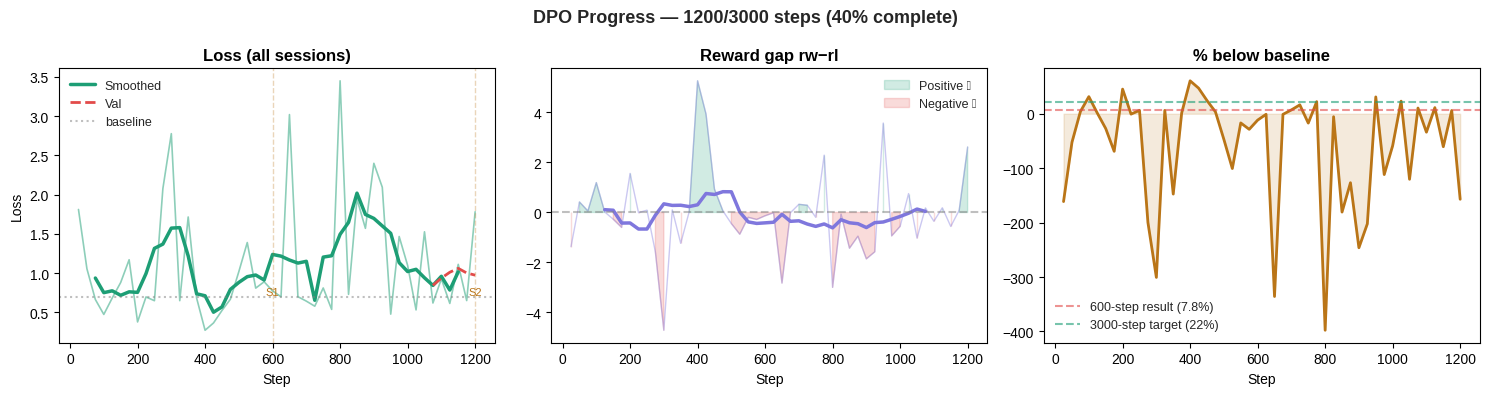

Saved: /kaggle/working/dpo_outputs/progress_step1200.png
Loss improvement : -157.1% below baseline
Max reward gap   : 5.267


In [3]:
# =============================================================
# DPO RESUMABLE TRAINING — FIXED CHECKPOINT SAVING
# The key fix: checkpoint is zipped so it appears clearly
# in Kaggle Output tab and can be downloaded/re-uploaded
# =============================================================




# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 2 — Imports                                       ║
# ╚══════════════════════════════════════════════════════════╝
import os, gc, json, time, glob, shutil, zipfile
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.optim import RMSprop
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Transformers : {__import__('transformers').__version__}")
print(f"PyTorch      : {torch.__version__}")
print(f"GPU          : {torch.cuda.get_device_name(0)}")
print(f"VRAM         : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"Device       : {device}")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 3 — Config                                        ║
# ╚══════════════════════════════════════════════════════════╝
CONFIG = {
    "model_name"         : "gpt2-medium",
    "train_samples"      : 5000,
    "val_samples"        : 400,
    "beta"               : 0.1,
    "lr"                 : 1e-6,       # safe stable value
    "batch_size"         : 4,
    "max_length"         : 192,
    "dtype"              : torch.float32,
    "steps_per_session"  : 600,
    "total_steps"        : 3000,
    "warmup_steps"       : 150,        # longer warmup = stable
    "log_every"          : 25,
    "val_every"          : 200,
    "output_dir"         : "/kaggle/working/dpo_outputs",
}

CKPT_DIR     = f"{CONFIG['output_dir']}/checkpoints"
HISTORY_FILE = f"{CONFIG['output_dir']}/full_history.json"
ZIP_DIR      = f"{CONFIG['output_dir']}/zipped"   # ← NEW

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(ZIP_DIR,  exist_ok=True)

print(f"Steps/session : {CONFIG['steps_per_session']}")
print(f"Total target  : {CONFIG['total_steps']}")
print(f"LR            : {CONFIG['lr']}")
print(f"Warmup steps  : {CONFIG['warmup_steps']}")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 4 — Utilities + FIXED checkpoint save/load        ║
# ╚══════════════════════════════════════════════════════════╝
def free_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def gpu_mem(label=""):
    used  = torch.cuda.memory_allocated()/1e9
    total = torch.cuda.get_device_properties(0).total_memory/1e9
    print(f"  [VRAM {label}] {used:.2f}/{total:.1f} GB")

def save_checkpoint(model, tokenizer, step, history):
    """
    Save model weights + history.
    Also creates a ZIP file so it shows up clearly in
    Kaggle Output tab and can be downloaded in one click.
    """
    # Save model files
    ckpt_path = os.path.join(CKPT_DIR, f"step_{step}")
    os.makedirs(ckpt_path, exist_ok=True)
    model.save_pretrained(ckpt_path)
    tokenizer.save_pretrained(ckpt_path)

    # Save history
    with open(HISTORY_FILE, "w") as f:
        json.dump(history, f)

    # ── KEY FIX: zip the checkpoint folder ──────────────
    # This makes it visible and downloadable in Kaggle Output
    zip_path = os.path.join(ZIP_DIR, f"checkpoint_step_{step}.zip")
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
        # Add all model files
        for fname in os.listdir(ckpt_path):
            zf.write(
                os.path.join(ckpt_path, fname),
                arcname=f"step_{step}/{fname}"
            )
        # Add history file too
        zf.write(HISTORY_FILE, arcname="full_history.json")

    zip_size = os.path.getsize(zip_path) / 1e6
    print(f"\n  Model saved  → checkpoints/step_{step}/")
    print(f"  ZIP saved    → zipped/checkpoint_step_{step}.zip  ({zip_size:.0f} MB)")
    print(f"  History saved → {len(history['step'])} total entries")
    print(f"\n  ← This ZIP file will appear in Kaggle Output tab")
    print(f"  ← Download it to continue in next session")


# def find_latest_checkpoint():
#     """Find highest step_N folder with valid model files."""
#     folders = glob.glob(os.path.join(CKPT_DIR, "step_*"))
#     valid   = []
#     for f in folders:
#         try:
#             n = int(os.path.basename(f).replace("step_", ""))
#             if os.path.exists(os.path.join(f, "config.json")):
#                 valid.append((n, f))
#         except ValueError:
#             continue
#     if not valid:
#         return None, 0
#     return max(valid, key=lambda x: x[0])


# def load_history():
#     if os.path.exists(HISTORY_FILE):
#         with open(HISTORY_FILE) as f:
#             h = json.load(f)
#         last = max(h["step"]) if h.get("step") else 0
#         print(f"  History loaded: {len(h['step'])} entries, up to step {last}")
#         return h
#     print("  No history found — starting fresh")
#     return {k:[] for k in ["step","train_loss","val_loss","rw","rl","gap"]}

def find_latest_checkpoint():
    """Find highest step_N folder and return step as an INTEGER."""
    folders = glob.glob(os.path.join(CKPT_DIR, "step_*"))
    valid = []
    for f in folders:
        try:
            # Folder name se number nikal kar use int() mein convert karna zaroori hai
            folder_name = os.path.basename(f)
            step_num = int(folder_name.replace("step_", "")) 
            
            if os.path.exists(os.path.join(f, "config.json")):
                valid.append((step_num, f))
        except (ValueError, IndexError):
            continue
            
    if not valid:
        return None, 0
    
    # Sabse bara step number aur uska path return karein
    best_step, best_path = max(valid, key=lambda x: x[0])
    return best_path, int(best_step) # Ensure it's an int
# # ╔══════════════════════════════════════════════════════════╗
# # ║  CELL 5 — Detect session                                ║
# # ╚══════════════════════════════════════════════════════════╝

# # ── Check if checkpoint was uploaded from previous session ──
# # In sessions 2-5, you upload the ZIP as a Kaggle Dataset
# # This cell extracts it automatically if found
# INPUT_DIR = "/kaggle/input"

# for root, dirs, files in os.walk(INPUT_DIR):
#     for fname in files:
#         if fname.startswith("checkpoint_step_") and fname.endswith(".zip"):
#             zip_src = os.path.join(root, fname)
#             print(f"Found uploaded checkpoint: {zip_src}")
#             print("Extracting ...")
#             with zipfile.ZipFile(zip_src, "r") as zf:
#                 zf.extractall(CONFIG["output_dir"])
#             print("Extracted successfully.")
#             # Move history if extracted to root
#             extracted_hist = os.path.join(CONFIG["output_dir"], "full_history.json")
#             if os.path.exists(extracted_hist):
#                 print(f"History file found in zip.")

# # Now detect session
# ckpt_path, start_step = find_latest_checkpoint()
# end_step    = start_step + CONFIG["steps_per_session"]
# session_num = (start_step // CONFIG["steps_per_session"]) + 1

# if ckpt_path:
#     model_to_load = ckpt_path
# else:
#     model_to_load = CONFIG["model_name"]

# print("\n" + "="*55)
# if ckpt_path is None:
#     print(f"SESSION 1 — Starting from scratch")
# else:
#     print(f"SESSION {session_num} — Resuming from step {start_step}")
#     print(f"  Checkpoint: {ckpt_path}")
# print(f"  This session : step {start_step} → {end_step}")
# print(f"  Remaining    : {CONFIG['total_steps'] - end_step} steps after this")
# print("="*55)

# if start_step >= CONFIG["total_steps"]:
#     print("ALL 3000 STEPS DONE — skip to Cell 11")




# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 5 — Detect session (FIXED FOR EXTRACTED DATASETS)  ║
# ╚══════════════════════════════════════════════════════════╝

import shutil

INPUT_DIR = "/kaggle/input"
WORKING_DIR = CONFIG["output_dir"]

# 1. Search for checkpoints in /kaggle/input (extracted or zip)
for root, dirs, files in os.walk(INPUT_DIR):
    # Case A: Check if it's already extracted (looking for step_ folders)
    for dname in dirs:
        if dname.startswith("step_"):
            src_folder = os.path.join(root, dname)
            dest_folder = os.path.join(CKPT_DIR, dname)
            if not os.path.exists(dest_folder):
                print(f"Found extracted checkpoint folder: {src_folder}")
                shutil.copytree(src_folder, dest_folder, dirs_exist_ok=True)
                print(f"Copied to {dest_folder}")

    # Case B: Check for full_history.json
    for fname in files:
        if fname == "full_history.json":
            src_hist = os.path.join(root, fname)
            if not os.path.exists(HISTORY_FILE):
                shutil.copy(src_hist, HISTORY_FILE)
                print(f"Copied history file to {HISTORY_FILE}")

        # Case C: Check for .zip (original logic as backup)
        if fname.startswith("checkpoint_step_") and fname.endswith(".zip"):
            zip_src = os.path.join(root, fname)
            print(f"Found zip checkpoint: {zip_src}. Extracting...")
            with zipfile.ZipFile(zip_src, "r") as zf:
                zf.extractall(WORKING_DIR)
            print("Extracted successfully.")

# Now detect session from /kaggle/working
ckpt_path, start_step = find_latest_checkpoint()
end_step    = start_step + CONFIG["steps_per_session"]

session_num = (start_step // CONFIG["steps_per_session"]) + 1

if ckpt_path:
    model_to_load = ckpt_path
else:
    model_to_load = CONFIG["model_name"]

print("\n" + "="*55)
if ckpt_path is None:
    print(f"SESSION 1 — Starting from scratch")
else:
    print(f"SESSION {session_num} — Resuming from step {start_step}")
    print(f"  Checkpoint: {ckpt_path}")
print(f"  This session : step {start_step} → {end_step}")
print("="*55)


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 6 — Load models                                   ║
# ╚══════════════════════════════════════════════════════════╝
free_gpu()
gpu_mem("before loading")

print(f"\nLoading tokenizer ...")
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id
tokenizer.padding_side = "left"

print(f"Loading policy model from: {model_to_load}")
policy_model = AutoModelForCausalLM.from_pretrained(
    model_to_load,
    dtype             = CONFIG["dtype"],
    low_cpu_mem_usage = True,
).to(device)
policy_model.train()

print(f"Loading reference model (always base) ...")
ref_model = AutoModelForCausalLM.from_pretrained(
    CONFIG["model_name"],
    dtype             = CONFIG["dtype"],
    low_cpu_mem_usage = True,
).to(device)
ref_model.eval()
for p in ref_model.parameters():
    p.requires_grad = False

gpu_mem("after loading both models")
print(f"Policy model params: {sum(p.numel() for p in policy_model.parameters())/1e6:.0f}M")
print("Models ready.")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 7 — DPO loss                                      ║
# ╚══════════════════════════════════════════════════════════╝
import torch
import torch.nn.functional as F

def get_log_probs(model, input_ids, attention_mask, labels):
    ctx = torch.enable_grad() if model.training else torch.no_grad()
    with ctx:
        out = model(input_ids=input_ids, attention_mask=attention_mask)
    logits  = out.logits[:,:-1,:].contiguous().float()
    targets = labels[:,1:].contiguous()
    logits  = torch.clamp(logits, -100, 100)
    lp      = F.log_softmax(logits, dim=-1)
    tlp     = lp.gather(2, targets.clamp(min=0).unsqueeze(2)).squeeze(2)
    mask    = (targets != -100).float()
    tlp     = torch.nan_to_num(tlp, nan=0.0)
    return (tlp * mask).sum(dim=-1)

def dpo_loss_fn(policy_model, ref_model, batch, beta):
    pi_w = get_log_probs(policy_model,batch["ids_w"],batch["mask_w"],batch["lbl_w"])
    pi_l = get_log_probs(policy_model,batch["ids_l"],batch["mask_l"],batch["lbl_l"])
    with torch.no_grad():
        ref_w = get_log_probs(ref_model,batch["ids_w"],batch["mask_w"],batch["lbl_w"])
        ref_l = get_log_probs(ref_model,batch["ids_l"],batch["mask_l"],batch["lbl_l"])
    rw     = beta * (pi_w - ref_w)
    rl     = beta * (pi_l - ref_l)
    margin = torch.clamp(rw - rl, -10, 10)
    loss   = -F.logsigmoid(margin).mean()
    if torch.isnan(loss):
        loss = torch.tensor(0.6931, requires_grad=True, device=device)
    return loss, rw.detach().mean(), rl.detach().mean()

print("DPO loss ready.")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 8 — Dataset                                       ║
# ╚══════════════════════════════════════════════════════════╝
import torch

print("Loading dataset ...")
raw_train = load_dataset("Anthropic/hh-rlhf",
                         split=f"train[:{CONFIG['train_samples']}]")
raw_val   = load_dataset("Anthropic/hh-rlhf",
                         split=f"test[:{CONFIG['val_samples']}]")

def tokenise_pair(example):
    def encode(text):
        marker = "\n\nAssistant:"
        cut    = text.rfind(marker)+len(marker) if marker in text else len(text)//2
        p_len  = tokenizer(text[:cut], max_length=CONFIG["max_length"],
                           truncation=True,
                           return_tensors="pt")["input_ids"].shape[1]
        enc    = tokenizer(text, max_length=CONFIG["max_length"],
                           truncation=True, padding="max_length",
                           return_tensors="pt")
        labels = enc["input_ids"].clone()
        labels[0,:p_len] = -100
        labels[enc["attention_mask"]==0] = -100
        return enc["input_ids"].squeeze(0), enc["attention_mask"].squeeze(0), labels.squeeze(0)
    iw,mw,lw = encode(example["chosen"])
    il,ml,ll = encode(example["rejected"])
    return {"ids_w":iw,"mask_w":mw,"lbl_w":lw,
            "ids_l":il,"mask_l":ml,"lbl_l":ll}

cols      = raw_train.column_names
tok_train = raw_train.map(tokenise_pair, remove_columns=cols, desc="Train")
tok_val   = raw_val.map(tokenise_pair,   remove_columns=cols, desc="Val")
tok_train.set_format("torch")
tok_val.set_format("torch")

train_loader = DataLoader(tok_train, batch_size=CONFIG["batch_size"],
                          shuffle=True, drop_last=True)
val_loader   = DataLoader(tok_val,   batch_size=CONFIG["batch_size"],
                          shuffle=False, drop_last=True)
print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 9 — Training loop                                 ║
# ╚══════════════════════════════════════════════════════════╝
import numpy as np
from torch.optim import RMSprop

history   = load_history()
optimizer = RMSprop(policy_model.parameters(), lr=CONFIG["lr"])
scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor = 0.01 if start_step == 0 else 1.0,
    end_factor   = 1.0,
    total_iters  = CONFIG["warmup_steps"],
)

data_iter = iter(train_loader)
best_val  = float("inf")
nan_count = 0
t0        = time.time()

print(f"\n{'='*55}")
print(f"  SESSION {session_num} | Steps {start_step+1} → {end_step}")
print(f"  β={CONFIG['beta']} | lr={CONFIG['lr']} | batch={CONFIG['batch_size']}")
print(f"{'='*55}")

policy_model.train()

for local_step in range(1, CONFIG["steps_per_session"]+1):
    global_step = start_step + local_step

    try:
        batch = next(data_iter)
    except StopIteration:
        data_iter = iter(train_loader)
        batch     = next(data_iter)

    batch = {k: v.to(device) for k, v in batch.items()}
    optimizer.zero_grad()

    loss, rw, rl = dpo_loss_fn(policy_model, ref_model,
                                batch, CONFIG["beta"])

    if torch.isnan(loss) or torch.isinf(loss):
        nan_count += 1
        if nan_count % 10 == 0:
            print(f"  WARNING: {nan_count} nan batches skipped")
        continue
    nan_count = 0

    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_model.parameters(), 1.0)
    optimizer.step()

    if start_step == 0 and local_step <= CONFIG["warmup_steps"]:
        scheduler.step()

    if global_step % CONFIG["log_every"] == 0:
        elapsed = (time.time()-t0)/60
        eta     = (elapsed/local_step)*(CONFIG["steps_per_session"]-local_step)
        gap     = (rw-rl).item()
        pct     = (0.6931-loss.item())/0.6931*100
        history["step"].append(global_step)
        history["train_loss"].append(loss.item())
        history["rw"].append(rw.item())
        history["rl"].append(rl.item())
        history["gap"].append(gap)
        print(f"Step {global_step:5d} | loss={loss.item():.4f} ({pct:+.1f}%) | "
              f"rw={rw.item():+.3f} | rl={rl.item():+.3f} | "
              f"gap={gap:+.3f} | ETA {eta:.0f}m")

    if global_step % CONFIG["val_every"] == 0:
        policy_model.eval()
        vlosses = []
        with torch.no_grad():
            for vb in list(val_loader)[:8]:
                vb = {k:v.to(device) for k,v in vb.items()}
                vl,_,_ = dpo_loss_fn(policy_model,ref_model,vb,CONFIG["beta"])
                if not torch.isnan(vl):
                    vlosses.append(vl.item())
        if vlosses:
            val_loss = float(np.mean(vlosses))
            history["val_loss"].append(val_loss)
            pct_v    = (0.6931-val_loss)/0.6931*100
            mark     = " ★" if val_loss < best_val else ""
            best_val = min(best_val, val_loss)
            print(f"         → val={val_loss:.4f} ({pct_v:.1f}% below baseline){mark}")
        policy_model.train()

# ── Save checkpoint + ZIP at end of session ──────────────────
save_checkpoint(policy_model, tokenizer, end_step, history)

total_min = (time.time()-t0)/60
print(f"\nSession {session_num} done in {total_min:.1f} min")
print(f"Progress: {end_step} / {CONFIG['total_steps']} steps")

remaining = CONFIG["total_steps"] - end_step
if remaining > 0:
    print(f"\n{'='*55}")
    print("HOW TO CONTINUE TO NEXT SESSION:")
    print("="*55)
    print(f"1. Go to Kaggle Output tab (right side panel)")
    print(f"2. Find: dpo_outputs/zipped/checkpoint_step_{end_step}.zip")
    print(f"3. Download that ZIP file to your computer")
    print(f"4. Go to kaggle.com/datasets → New Dataset")
    print(f"   Upload the ZIP, name it: dpo-step-{end_step}")
    print(f"5. Open same notebook in new Kaggle session")
    print(f"6. Add Data → your dataset dpo-step-{end_step}")
    print(f"7. Run All → Cell 5 extracts ZIP automatically")
    print(f"   Will print: SESSION {session_num+1} from step {end_step}")
    print("="*55)
else:
    print("\nALL 3000 STEPS COMPLETE — run Cell 10 for plots")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 10 — Progress plot                                ║
# ╚══════════════════════════════════════════════════════════╝
history = load_history()

if history.get("step"):
    fig, axes = plt.subplots(1, 3, figsize=(15,4))
    plt.style.use("seaborn-v0_8-whitegrid")
    s = history["step"]

    # Loss
    axes[0].plot(s, history["train_loss"], color="#1D9E75", lw=1.2, alpha=0.5)
    if len(s) >= 5:
        sm = np.convolve(history["train_loss"], np.ones(5)/5, "valid")
        axes[0].plot(s[2:2+len(sm)], sm, color="#1D9E75", lw=2.5, label="Smoothed")
    if history["val_loss"]:
        axes[0].plot(s[-len(history["val_loss"]):], history["val_loss"],
                     color="#E24B4A", lw=2, ls="--", label="Val")
    axes[0].axhline(0.6931, color="gray", ls=":", alpha=0.5, label="baseline")
    for sn in range(1,6):
        b = sn * CONFIG["steps_per_session"]
        if b <= max(s):
            axes[0].axvline(b, color="#BA7517", ls="--", alpha=0.3, lw=1)
            axes[0].text(b, 0.72, f"S{sn}", fontsize=8,
                         color="#BA7517", ha="center")
    axes[0].set_title("Loss (all sessions)", fontweight="bold")
    axes[0].set_xlabel("Step"); axes[0].set_ylabel("Loss")
    axes[0].legend(fontsize=9)

    # Gap
    gap_arr = np.array(history["gap"])
    axes[1].plot(s, gap_arr, color="#7F77DD", lw=1, alpha=0.4)
    if len(gap_arr) >= 10:
        sg = np.convolve(gap_arr, np.ones(10)/10, "valid")
        axes[1].plot(s[4:4+len(sg)], sg, color="#7F77DD", lw=2.5)
    axes[1].axhline(0, color="gray", ls="--", alpha=0.5)
    axes[1].fill_between(s, gap_arr, 0, where=gap_arr>0,
                          alpha=0.2, color="#1D9E75", label="Positive ✓")
    axes[1].fill_between(s, gap_arr, 0, where=gap_arr<0,
                          alpha=0.2, color="#E24B4A", label="Negative ✗")
    axes[1].set_title("Reward gap rw−rl", fontweight="bold")
    axes[1].set_xlabel("Step"); axes[1].legend(fontsize=9)

    # % improvement
    pct = [(0.6931-l)/0.6931*100 for l in history["train_loss"]]
    axes[2].plot(s, pct, color="#BA7517", lw=2)
    axes[2].fill_between(s, pct, alpha=0.15, color="#BA7517")
    axes[2].axhline(7.8,  color="#E24B4A", ls="--", alpha=0.6,
                    label="600-step result (7.8%)")
    axes[2].axhline(22,   color="#1D9E75", ls="--", alpha=0.6,
                    label="3000-step target (22%)")
    axes[2].set_title("% below baseline", fontweight="bold")
    axes[2].set_xlabel("Step"); axes[2].legend(fontsize=9)

    done = max(s)/CONFIG["total_steps"]*100
    plt.suptitle(f"DPO Progress — {max(s)}/{CONFIG['total_steps']} steps "
                 f"({done:.0f}% complete)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    out = f"{CONFIG['output_dir']}/progress_step{max(s)}.png"
    plt.savefig(out, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")
    print(f"Loss improvement : {pct[-1]:.1f}% below baseline")
    print(f"Max reward gap   : {max(history['gap']):.3f}")

In [ ]:

# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 11 — Final evaluation (run only after step 3000)  ║
# ╚══════════════════════════════════════════════════════════╝
# Only run this cell when all 3000 steps are complete

TEST_PROMPTS = [
    "\n\nHuman: What is the best way to learn programming?\n\nAssistant:",
    "\n\nHuman: Can you explain what a neural network is?\n\nAssistant:",
    "\n\nHuman: How do I stay motivated while studying?\n\nAssistant:",
    "\n\nHuman: What makes a good software engineer?\n\nAssistant:",
    "\n\nHuman: Explain reinforcement learning simply.\n\nAssistant:",
    "\n\nHuman: How do I improve my writing skills?\n\nAssistant:",
    "\n\nHuman: What is the difference between AI and machine learning?\n\nAssistant:",
    "\n\nHuman: Give me tips for a technical job interview.\n\nAssistant:",
]

def generate(model, prompt, max_new=100, temp=0.7):
    inputs = tokenizer(
        prompt,
        return_tensors = "pt",
        truncation     = True,
        max_length     = CONFIG["max_length"] - max_new,
        padding        = False,
    ).to(device)
    model.eval()
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens     = max_new,
            do_sample          = True,
            temperature        = temp,
            top_p              = 0.95,
            repetition_penalty = 1.3,
            pad_token_id       = tokenizer.eos_token_id,
            eos_token_id       = tokenizer.eos_token_id,
        )
    new_tokens = out[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


print("=" * 60)
print("FINAL EVALUATION: SFT baseline vs DPO (3000 steps)")
print("=" * 60)

results  = []
dpo_wins = 0

for i, prompt in enumerate(TEST_PROMPTS):
    q       = prompt.replace("\n\nHuman:","").replace(
              "\n\nAssistant:","").strip()
    sft_ans = generate(ref_model,    prompt)
    dpo_ans = generate(policy_model, prompt)

    def score(t):
        if not t or len(t) < 15: return 0.0
        w = t.split()
        return min(len(set(w))/max(len(w),1),1.0) * min(len(w)/50,1.0)

    sft_s  = score(sft_ans)
    dpo_s  = score(dpo_ans)
    winner = "DPO" if dpo_s > sft_s else "SFT" if sft_s > dpo_s else "TIE"
    if winner == "DPO":
        dpo_wins += 1

    print(f"\n── Q{i+1}: {q[:60]}")
    print(f"   SFT [{sft_s:.2f}]: {sft_ans[:160]}")
    print(f"   DPO [{dpo_s:.2f}]: {dpo_ans[:160]}")
    print(f"   Winner: {winner}")

    results.append({
        "prompt":q, "sft":sft_ans, "dpo":dpo_ans,
        "sft_score":sft_s, "dpo_score":dpo_s, "winner":winner,
    })

win_rate = dpo_wins / len(results)
print(f"\nDPO win rate : {dpo_wins}/{len(results)} ({win_rate:.0%})")

with open(f"{CONFIG['output_dir']}/final_qualitative.json", "w") as f:
    json.dump(results, f, indent=2)



In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 12 — Final summary numbers for report             ║
# ╚══════════════════════════════════════════════════════════╝
history = load_history()

final_loss = history["train_loss"][-1]
drop_pct   = (0.6931 - final_loss) / 0.6931 * 100
max_gap    = max(history["gap"])
final_gap  = history["gap"][-1]
pos_pct    = sum(1 for g in history["gap"] if g > 0) / len(history["gap"]) * 100

print("\n" + "=" * 55)
print("FINAL SUMMARY — paste into your report")
print("=" * 55)
print(f"Model              : {CONFIG['model_name']}")
print(f"Total steps        : {max(history['step'])}")
print(f"Batch size         : {CONFIG['batch_size']}")
print(f"Learning rate      : {CONFIG['lr']}")
print(f"Beta               : {CONFIG['beta']}")
print()
print(f"Initial loss       : 0.6931  (log(2) baseline)")
print(f"Final train loss   : {final_loss:.4f}")
print(f"Loss improvement   : {drop_pct:.1f}% below baseline")
print(f"Final reward gap   : {final_gap:.4f}")
print(f"Max reward gap     : {max_gap:.4f}")
print(f"Positive gap steps : {pos_pct:.0f}%")
print(f"DPO win rate       : {win_rate:.0%} vs SFT baseline")
print("=" * 55)